In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows
import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats

In [2]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [3]:
uvh5name[4*275]

'/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.49903.sum.uvh5'

In [4]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  
pol=uvd1.polarization_array[0]
uvd1.read(Model_complete_file, polarizations=pol) 
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [12]:

filter_name="Main_lobe_20_mHz"
filter_name_2="Notch_filter_40_mHz"
lst="0h"
spw="low"

In [13]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
freqs = uvd1.freq_array*1e-6
dt=((lsts[1]-lsts[0])*60*60)/4
# t_total=(800*dt)/2
# t_total/3600

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [14]:
hd = io.HERAData(uvh5name[0])
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))


In [58]:
N=125

def filter_data(cal_data):
    cal_data_filtered=[]
    for bl in cal_data:
        blvec = (antpos[np.where(ants==bl[0])] - antpos[np.where(ants==bl[1])])
        
        if np.linalg.norm(blvec)-29<2:
            

            cal_data_filtered.append(cal_data[bl])
    
    return cal_data_filtered
    
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

  
    cal_all_data=[]
    # for n in range(N):
    #     if n<135 or n>143:
  
    #         i=4*n
    #         cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
    #         cal_all_data.append(filter_data(cal_data))  
            
    for n in range(N):
        if n<135 or n>143:
            i=4*n+1
    
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()

            cal_all_data.append(filter_data(cal_data))


    # for n in range(N):
    #     if n<135 or n>143:
    #         i=4*n+2
        
    #         cal_data = np.load(file_name+uvh5name[i][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
        
    #         cal_all_data.append(filter_data(cal_data))              

  
    return cal_all_data        

In [59]:
cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)
cal_data_full_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_full_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

cal_data_gleam_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_gleam_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

FileNotFoundError: [Errno 2] No such file or directory: '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/abs_calibrated_data_Main_lobe_20_mHz_full_.2459861.25319.sum.uvh5_1h_low.npy'

In [ ]:
# hd_gleam_model = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5")
# hd_gleam_model.read()
# data_gleam,_,_=hd_gleam_model.build_datacontainers()

# hd_gleam_model = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_diffuse_model_final_"+lst+"_"+spw+".uvh5")
# hd_gleam_model.read()
# data_diffuse,_,_=hd_gleam_model.build_datacontainers()

In [ ]:
# hd_gleam_model_filter = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/filtered_single_pol_combined_gleam_"+lst+"_"+spw+".uvh5")
# hd_gleam_model_filter.read()
# data_gleam_filter,_,_=hd_gleam_model_filter.build_datacontainers()

# hd_diffuse_model_filter = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/filtered_single_pol_combined_diffuse_"+lst+"_"+spw+".uvh5")
# hd_diffuse_model_filter.read()
# data_diffuse_filter,_,_=hd_diffuse_model_filter.build_datacontainers()

In [ ]:
# bls=reds[0]
# model_bls=[]
# for bl in bls:
#     bls_yy=(bl[0],bl[1],'yy')
#     if bls_yy in data_diffuse:
#         model_bls.append(bls_yy)

        

In [ ]:
# data_gleam_filter[model_bls[0]].shape

In [14]:

def plot_redundant_abs(start=0, N=10, freqs=freqs, cal_data="", title_name=""):
    for n in range (N):
        i=n+start
        for bl in range(len(cal_data[i])):
            plt.semilogy(freqs[0:-1],np.abs(cal_data[i][bl][0,:][0:-1]))
    plt.title(title_name)
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("|V|[Jy]")
    plt.savefig(title_name+".pdf")

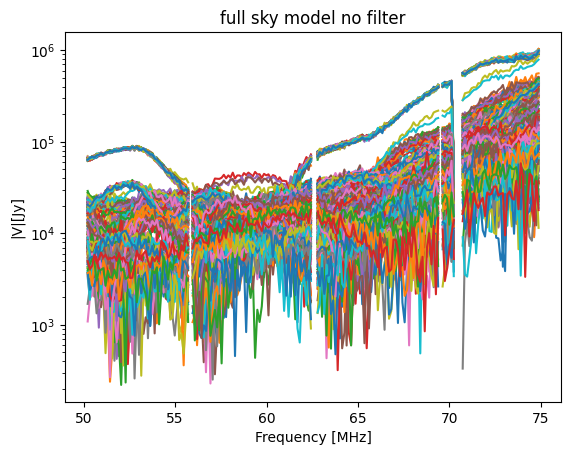

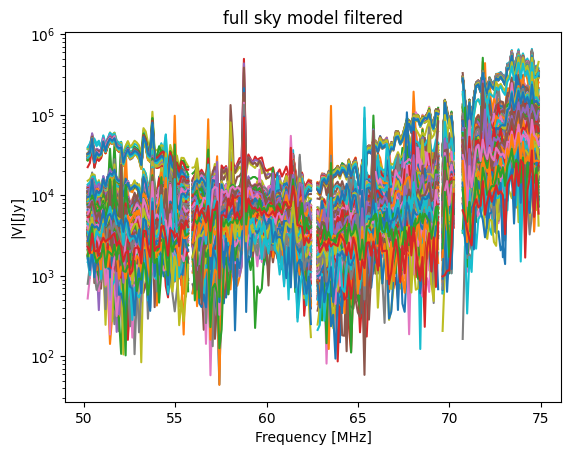

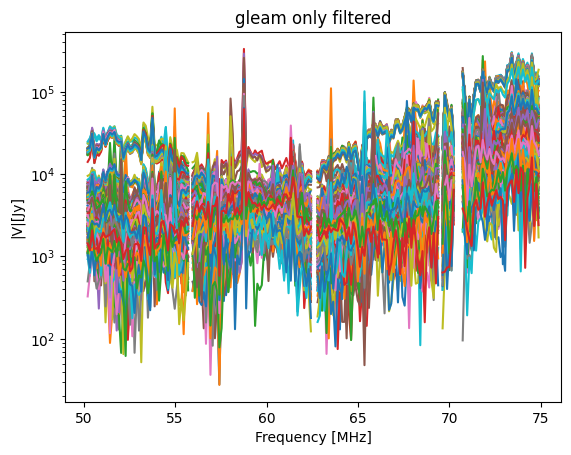

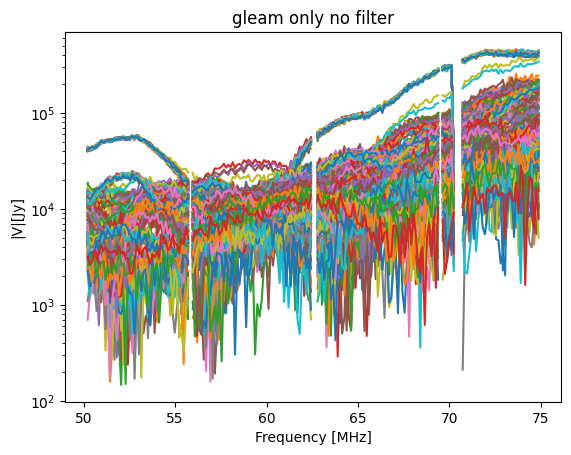

In [15]:
plt.figure()
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_full, title_name="full sky model no filter")

plt.figure()
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_full_filter, title_name="full sky model filtered")

plt.figure()
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="gleam only filtered")

plt.figure()
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_gleam, title_name="gleam only no filter")

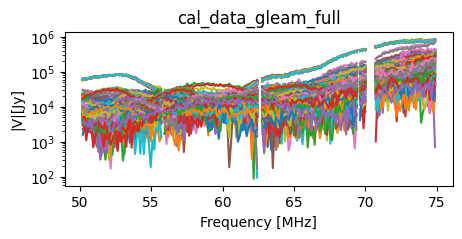

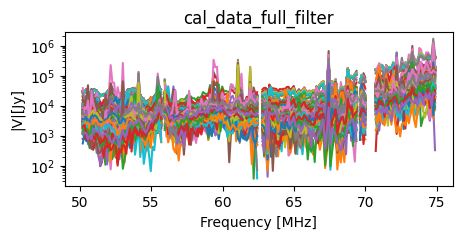

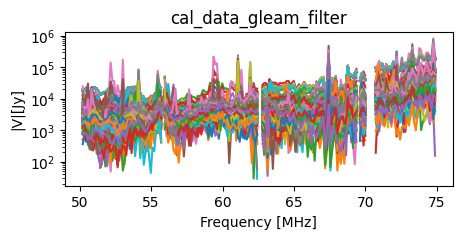

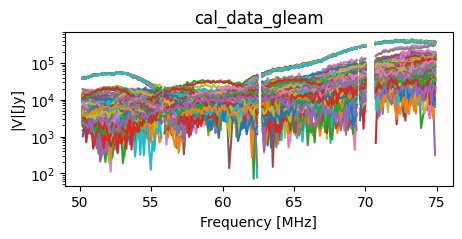

In [16]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=3, N=1, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_gleam_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=3, N=1, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=3, N=1, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=3, N=1, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

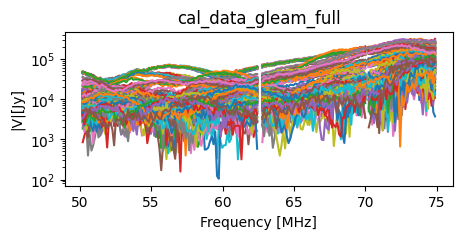

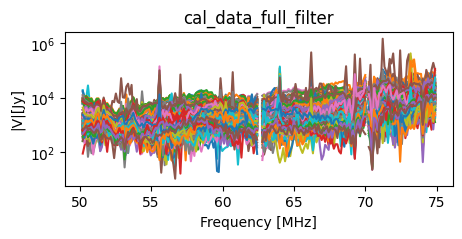

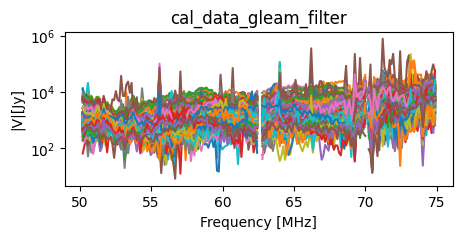

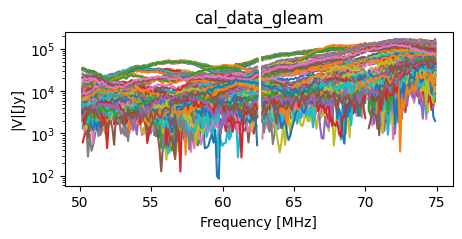

In [17]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=1, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_gleam_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=1, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=1, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=1, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

IndexError: list index out of range

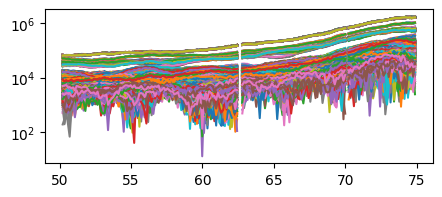

In [18]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=120, N=121, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=120, N=121, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=120, N=121, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=120, N=121, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

In [27]:
# raw_data=[]
# for i in range (10):
#     hd_data=io.HERAData("/net/sinatra/vault-ike/ntsikelelo/filtered_data/raw_data_vis_"+uvh5name[4(i+10)][43:69])

#     hd_data.read()
#     data_raw,_,_=hd_data.build_datacontainers()
#     raw_data.append(data_raw)

In [28]:
# def calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_full_abscal_", n_time=10, n_start=0, freqs=freqs, plot_cal_data=True):
#     cal_data=[]
#     for n in range(n_time):
#         i=n
#         gains_per_time=np.load(path_data+gains_name+uvh5name[4*(i+n_start)][43:69]+"_low.npy",allow_pickle=True).item()
#         data_cal=copy.deepcopy(data[i])
#         hc.apply_cal.calibrate_in_place(data_cal, gains_per_time)
#         cal_data.append(data_cal)
#     # if plot_cal_data:
#     #     plt.figure()
#     #     for bl in data_cal.keys():
#     #             plt.semilogy(freqs[50:-1],np.abs(cal_data[i][bl][0, 50:-1]))
#                 # plt.semilogy(freqs[50:-1],np.abs(cal_data[i][bl][1, 50:-1]))
     
#     return cal_data  

In [29]:
# cal_data_full_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_"+filter_name+"_gleam_flagged_abscal", n_time=10, n_start=0, freqs=freqs, plot_cal_data=True)
# cal_data_full_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_"+filter_name+"_gleam_flagged_abscal", n_time=10, n_start=90, freqs=freqs, plot_cal_data=True)

In [30]:
# cal_data_gleam_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_gleam_abscal", n_time=8, n_start=0, freqs=freqs, plot_cal_data=True)
# cal_data_gleam_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_gleam_abscal", n_time=10, n_start=20, freqs=freqs, plot_cal_data=True)

In [31]:
# cal_data_gleam_filter_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_Notch_filter_40_mHz_gleam_flagged_abscal", n_time=10, n_start=0, freqs=freqs, plot_cal_data=True)
# cal_data_gleam_filter_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_Notch_filter_40_mHz_gleam_flagged_abscal", n_time=10, n_start=90, freqs=freqs, plot_cal_data=True)

In [32]:
# def calculate_average_visility_amplitude(start=0, N=10, cal_data=cal_data_gleam):
#     data_temp=[]
#     for n in range (N):
#         i=n+start
#         for bls in cal_data[i]:
    
#             data_temp.append(np.mean(np.abs(cal_data[i][bls]), axis=0)[50:-1])
#     data_temp=np.array(data_temp)
#     return np.nanmean(data_temp, axis=0)

In [33]:
# for n in range (4):
#     i=n*10
#     plt.figure(figsize=(5,2))
#     gleam_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam)
#     # full_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full)
#     gleam_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam_filter)
#     full_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full_filter)
#     #plt.semilogy(freqs[50:-1], np.mean(np.abs((data_gleam[model_bls[0]]+data_diffuse[model_bls[0]])[i:(i+1)*10,50:-1]), axis=0),'m', label="model")
#     plt.semilogy(freqs[50:-1], gleam_average,'k', label="gleam_only")
#     # plt.semilogy(freqs[50:-1], full_average,'g', label="full")
#     plt.semilogy(freqs[50:-1], gleam_average_filter,'r', label="gleam_only_filter")
#     plt.semilogy(freqs[50:-1], full_average_filter,'b', label="full_filter")
    
#     plt.xlabel("Freq [MHz]")
#     plt.ylabel("|V| [Jy]")
#     if i==0:
#         plt.legend()
#     plt.title("LST = "+str(np.round(lsts[i],2)))
    

In [34]:
# for n in range (5):
#     i=(n+4)*10
#     plt.figure(figsize=(5,2))
#     gleam_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam)
#     full_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full)
#     gleam_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam_filter)
#     full_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full_filter)
#     full_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full_filter)
#     plt.semilogy(freqs[50:-1], np.mean(np.abs((data_gleam[model_bls[0]]+data_diffuse[model_bls[0]])[i:(i+1)*10,50:-1]), axis=0),'m', label="model")
#     plt.semilogy(freqs[50:-1], gleam_average,'k', label="gleam_only")
#     plt.semilogy(freqs[50:-1], full_average,'g', label="full")
#     plt.semilogy(freqs[50:-1], gleam_average_filter,'r', label="gleam_only_filter")
#     plt.semilogy(freqs[50:-1], full_average_filter,'b', label="full_filter")
#     plt.xlabel("Freq [MHz]")
#     plt.ylabel("|V| [Jy]")
#     if n==0:
#         plt.legend()
#     plt.title("LST = "+str(np.round(lsts[i],2)))

In [35]:
# cross_all_time=[]
# for t in range (1):
#     bls=[]
#     for key in cal_data_gleam[t].keys():
#         bls.append(key)
#     cross_all_bls=[]
#     for k in range (len(cal_data_gleam[t].keys())):
#         for i in range (len(cal_data_gleam[t].keys())):
#             if i>k:
#                 bls1=bls[k]
#                 bls2=bls[i]
#                 v_cross=cal_data_gleam[t][bls1][0,:]*np.conjugate(cal_data_gleam[t][bls2][0,:])
#                 cross_all_bls.append(v_cross)
#     cross_all_bls=np.array(cross_all_bls)
#     cross_all_time.append(np.mean(cross_all_bls, axis=0))

In [19]:
def vis_perform_delay_trans(freqs=freqs, data=""):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    
    print(len(data))
    data_full_bls=[]
    for t in range(len(data)):
        # print(t)
       
        for bls in range (len(data[t])):
            data_time_no_nans=data[t][bls][0,:][~np.isnan(data[t][bls][0,:])]
            freq_no_nans=freqs[~np.isnan(data[t][bls][0,:])]
            coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
            poly = np.poly1d(coeffs)
            x_fit=freqs
            y_fit=poly(x_fit)
            data_fitted=[]
            for i in range (data[t][bls][0,:].shape[0]):
                if np.isnan(data[t][bls][0,:][i]):
                    data_fitted.append(poly(x_fit[i]))
                else:
                    data_fitted.append(data[t][bls][0,:][i])
            data_fitted=np.array(data_fitted) 
           
            data_full_bls.append(data_fitted)
            
    data_full_bls=np.array(data_full_bls)
    print(data_full_bls.shape)
    # data_full_fitted=np.array(data_full_fitted)
    cross_power=[]
    for i in range (data_full_bls.shape[0]-1):
        # for k in range (130):
        #     if k>i:
               
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i+1]))
                cross_power.append(g0_delay*np.conjugate(g1_delay))
                #cross_power.append(np.abs(g0_delay))
                
    cross_power=np.array(cross_power)
    return data_full_bls, cross_power, tau

In [20]:
def vis_perform_delay_trans_model(freqs=freqs, data=""):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    cross_power=[]
    for i in range (data.shape[0]):
        g0_delay=np.fft.fftshift(np.fft.fft(window*data[i,:]))[index]
        cross_power.append(np.abs(g0_delay))
                
    cross_power=np.array(cross_power)
    return cross_power, tau_pos

In [60]:
n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam)
c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter)
c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter)
c4, p4, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full)

c5, p5, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch)
c6, p6, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter_notch)

125
(28502, 205)
125
(28536, 205)
125
(28536, 205)
125
(28639, 205)
125
(28382, 205)
125
(28382, 205)


In [61]:
# p.shape,len(cal_data_gleam)

In [62]:
# p0, tau=vis_perform_delay_trans_model(freqs=freqs, data=data_gleam[model_bls[0]][0:200])
# pd_filter, tau=vis_perform_delay_trans_model(freqs=freqs, data=data_gleam_filter[model_bls[0]][0:200]+data_diffuse_filter[model_bls[0]][0:200])
# p0_filter, tau=vis_perform_delay_trans_model(freqs=freqs, data=data_gleam_filter[model_bls[0]][0:200])
# pd, tau=vis_perform_delay_trans_model(freqs=freqs, data=data_gleam[model_bls[0]][0:200]+data_diffuse[model_bls[0]][0:200])

In [63]:
# p_ave0_filter= np.mean(p0_filter, axis=0)
# p_aved_filter= np.mean(pd_filter, axis=0)

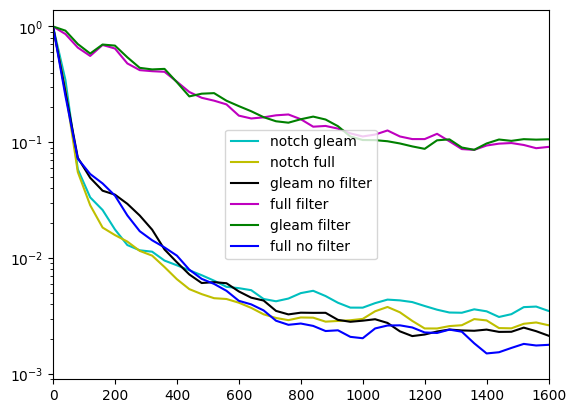

In [64]:


# p_ave0= np.mean(p0, axis=0)
# p_aved= np.mean(pd, axis=0)
p_ave= np.mean(p, axis=0)
p_ave2= np.mean(p2, axis=0)
p_ave3= np.mean(p3, axis=0)
p_ave4= np.mean(p4, axis=0)
p_ave5= np.mean(p5, axis=0)
p_ave6= np.mean(p6, axis=0)
plt.plot(tau, np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch gleam")
plt.plot(tau, np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau, np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
plt.semilogy(tau, np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
plt.semilogy(tau, np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="gleam filter")
plt.semilogy(tau, np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
# for i in range (100):
#     plt.plot(tau, np.abs(p[i,:]),'k')
#     plt.plot(tau, np.abs(p2[i,:]),'g')
#     plt.plot(tau, np.abs(p3[i,:]),'m')
plt.xlim([0,1600])
plt.legend()

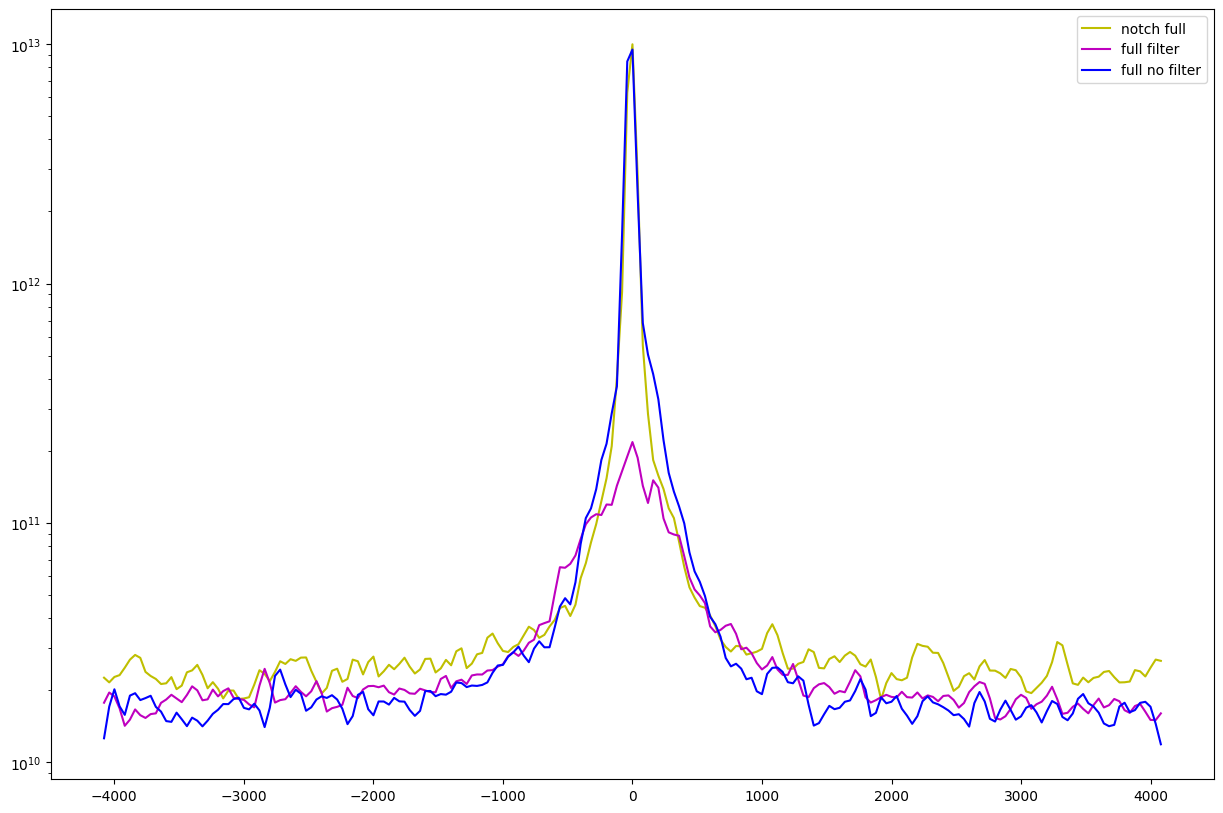

In [85]:
n=1e1
n2=1e1
plt.figure(figsize=(15,10))

# p_ave0= np.mean(p0, axis=0)
# p_aved= np.mean(pd, axis=0)
p_ave= np.mean(p, axis=0)
p_ave2= np.mean(p2, axis=0)
p_ave3= np.mean(p3, axis=0)
p_ave4= np.mean(p4, axis=0)
# p_ave5= np.mean(p5, axis=0)
# p_ave6= np.mean(p6, axis=0)
# plt.plot(tau, np.abs(p_ave5)*n,'c', label="notch gleam")
plt.plot(tau, np.abs(p_ave6)*n,'y', label="notch full")
# plt.semilogy(tau, np.abs(p_ave),'k', label="gleam no filter")
plt.semilogy(tau, np.abs(p_ave2)*n2,'m', label="full filter")
# plt.semilogy(tau, np.abs(p_ave3)*n2,'g', label="gleam filter")
plt.semilogy(tau, np.abs(p_ave4),'b', label="full no filter")
# for i in range (100):
#     plt.plot(tau, np.abs(p[i,:]),'k')
#     plt.plot(tau, np.abs(p2[i,:]),'g')
#     plt.plot(tau, np.abs(p3[i,:]),'m')
# plt.xlim([0,1600])
plt.legend()

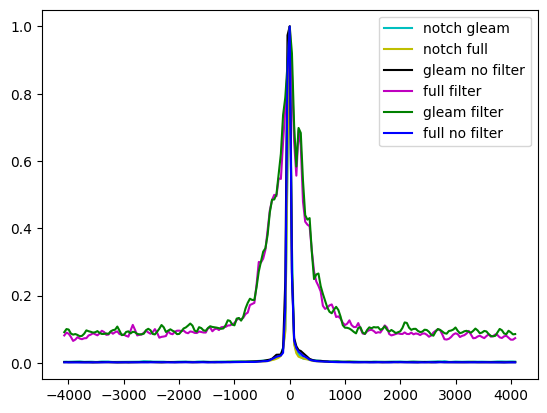

In [31]:
# p_ave0= np.mean(p0, axis=0)
# p_aved= np.mean(pd, axis=0)
p_ave= np.mean(p, axis=0)
p_ave2= np.mean(p2, axis=0)
p_ave3= np.mean(p3, axis=0)
p_ave4= np.mean(p4, axis=0)
p_ave5= np.mean(p5, axis=0)
p_ave6= np.mean(p6, axis=0)
plt.plot(tau, np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch gleam")
plt.plot(tau, np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.plot(tau, np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
plt.plot(tau, np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
plt.plot(tau, np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="gleam filter")
plt.plot(tau, np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
# for i in range (100):
#     plt.plot(tau, np.abs(p[i,:]),'k')
#     plt.plot(tau, np.abs(p2[i,:]),'g')
#     plt.plot(tau, np.abs(p3[i,:]),'m')
# plt.xlim([0,0.001600])
plt.legend()

In [25]:
N=200
def extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):
    cal_all_data=[]
    for n in range(N):
        i=4*n
        cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
        cal_all_data.append(cal_data) 
    # for n in range(N):
    #     i=4*n+1

    #     cal_data = np.load(file_name+uvh5name[i][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()
    
    #     # print(i)
    #     # print(cal_data)
    #     cal_all_data.append(cal_data) 

    # for n in range(N):
    #     if n>70 or n<60:
      
    #         i=4*n+2
    
    #         cal_data = np.load(file_name+uvh5name[i][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
        
    #         # print(i)
    #     # print(cal_data)
    #         cal_all_data.append(cal_data)    
    return cal_all_data        

In [26]:
#res_data_full=extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_full_filtered_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)
res_data_full_filter=extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_"+filter_name+"_full_filtered_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
res_data_full_filter_notch=extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_full_filtered_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

res_data_gleam_filter=extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_filtered_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
res_data_gleam_filter_notch=extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_filtered_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
#res_data_gleam=extrac_cal_data_res(file_name=path_data+"abs_calibrated_data_gleam_filtered_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

In [27]:

def plot_redundant_abs_res(start=0, N=10, freqs=freqs, cal_data="", title_name=""):
    res=[]
    for n in range (N):
        i=n+start
        for bls in cal_data[i]:
            res.append(np.abs(cal_data[i][bls][0][0:-1]))
    
    res=np.array(res)
    plt.semilogy(freqs[0:-1],np.mean(res, axis=0),label=title_name)
    plt.title(title_name)
    plt.xlabel("Freq [MHz]")
    plt.ylabel("|V|[Jy]")
    

In [28]:
# plt.figure(figsize=(5,2))
# plot_redundant_abs_res(start=60, N=1, freqs=freqs, cal_data=res_data_full_filter, title_name="cal_data_gleam_full")

plt.figure(figsize=(5,2))
plot_redundant_abs_res(start=0, N=399, freqs=freqs, cal_data=res_data_gleam_filter, title_name="main_lobe_filter")
# plt.figure(figsize=(5,2))
plot_redundant_abs_res(start=0, N=399, freqs=freqs, cal_data=res_data_gleam_filter_notch, title_name="notch_filter")
plt.legend()
# plt.figure(figsize=(5,2))
# plot_redundant_abs_res(start=60, N=1, freqs=freqs, cal_data=res_data_full_filter_notch, title_name="cal_data_gleam")

IndexError: list index out of range

<Figure size 500x200 with 0 Axes>

In [164]:
filter_name_2

'Notch_filter_40_mHz'

## Gain analysis

In [15]:
N=125
def extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for n in range (N):
        i=4*n
        g0=np.load(path_data+"gains/gains_full_flagged_abscal"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",allow_pickle=True).item()
        g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                g0_t=g0[ant][t,:]
                g1_t=g1[ant][t,:]
                g0_t_ave=np.nanmean(g0_t)
                g1_tn=(g1_t/np.nanmean(g1_t))*g0_t_ave
                gain_temp.append(g1_tn)
                
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)

    # for n in range (N):
    #     i=4*n+1
    #     g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_1h_"+spw+".npy",allow_pickle=True).item()
    #     gain_temp=[]
    #     for ant in g1:
    #         for t in range (1):
    #             gain_temp.append(g1[ant][t,:])
    #     gain_temp=np.array(gain_temp)
    #     gain_ave=np.mean(np.abs(gain_temp), axis=0)
    #     gains_gleam.append(gain_ave)    
    

    # for n in range (N):
    #     if n>70 or n<60:
    #         i=4*n+2
    #         g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_2h_"+spw+".npy",allow_pickle=True).item()
    #         gain_temp=[]
    #         for ant in g1:
    #             for t in range (1):
    #                 gain_temp.append(g1[ant][t,:])
    #         gain_temp=np.array(gain_temp)
    #         gain_ave=np.mean(np.abs(gain_temp), axis=0)
    #         gains_gleam.append(gain_ave)    
    gains_gleam=np.array(gains_gleam)

    return gains_gleam

gains_gleam_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name+"_full_flagged_abscal", N=N,uvh5name=uvh5name)

gains_full_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)

def flag_rfi(gains, f_0, f_1, freqs):
    index_flag=np.where((freqs>=f_0 ) & (freqs<=f_1))
    for t in range (gains.shape[0]):
        gains[t,:][index_flag]=np.ones(gains[t,:][index_flag].shape)*np.nan
    # print(gains[index_flag])
    return gains


flag_low=69.85
flag_high=71.20
gains_gleam=flag_rfi(gains=gains_gleam_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_gleam_filter=flag_rfi(gains=gains_gleam_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full=flag_rfi(gains=gains_full_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full_filter=flag_rfi(gains=gains_full_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)   

gains_full_filter_notch=flag_rfi(gains=gains_full_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 
gains_gleam_filter_notch=flag_rfi(gains=gains_gleam_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 

In [16]:
filter_name, filter_name_2, N

('Main_lobe_20_mHz', 'Notch_filter_40_mHz', 125)

In [17]:


def extract_antenna_gains_all_times(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[i]+".npy",allow_pickle=True).item()
        
        for ant in g1:
            gain_temp=[]
            for t in range (2):
                gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gains_gleam.append(np.mean(gain_temp,axis=0))
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam    

def produce_plots_every_n_time(n=10, N=N, gains=""):
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    plt.figure(figsize=(5,2))
                plt.plot(freqs[50:-1],gains[i,:][50:-1])
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")

def produce_plots_colour_every_n_time(n=10, N=N, gains=""):
    cl_al=[c['color'] for c in plt.rcParams['axes.prop_cycle']]
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    #plt.figure(figsize=(5,2))
                    cl=cl_al[m]
                plt.plot(freqs[50:-1],gains[i,:][50:-1], cl)
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")                
        
def produce_average_plots_every_n_time(n=10, N=N, gains="", lsts=lsts):
    for m in range (int(N/n)):
        gain_temp=[]
        for i in range (N):
            
            if n*m<=i and i<(m+1)*n:
                
                if i==m*n:
                    gain_temp.append(gains[i,:][50:-1])
        gain_temp=np.array(gain_temp)
        gains_ave=np.mean(gain_temp, axis=0)
                
        plt.plot(freqs[50:-1],gains_ave, label="lst ="+str(np.round(lsts[m*n],2)))    
        plt.xlabel("Freqs [MHz]")
        plt.ylabel("|g|")
        plt.legend()

# Extract gains

## Plots gains every 10*20s

In [18]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam)

In [19]:

# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter)

In [20]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full)

In [21]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full_filter)

## Plot average over with colour

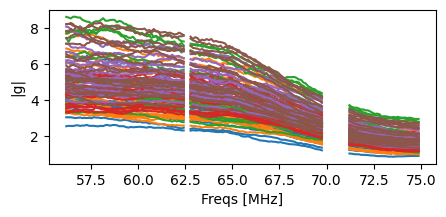

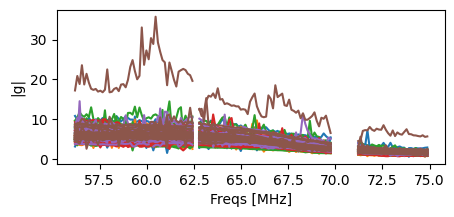

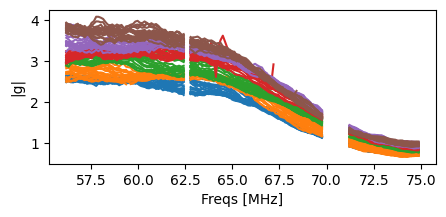

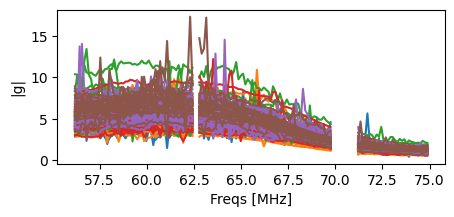

In [22]:
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam_filter_notch)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_full)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_full_filter_notch)

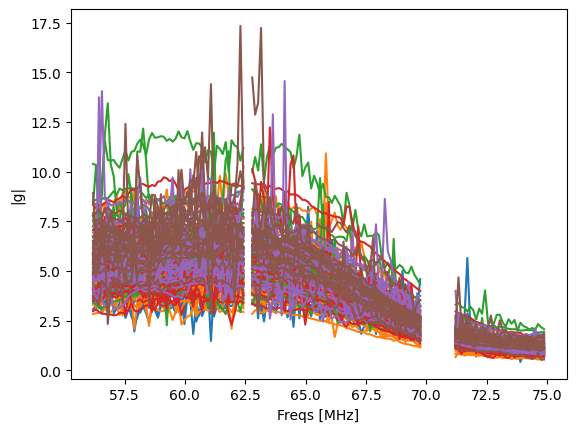

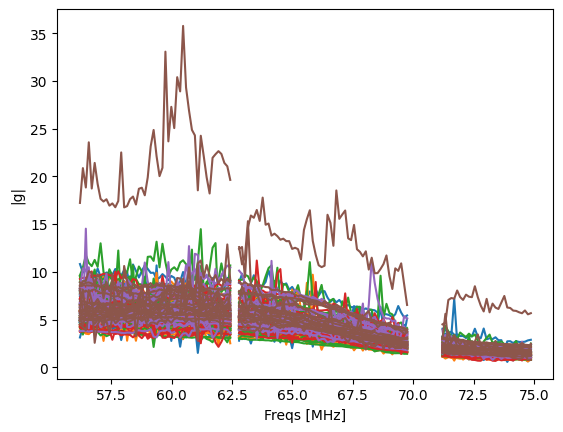

In [23]:
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_full_filter_notch)
plt.figure()
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam_filter_notch)

## Average gains over 10n

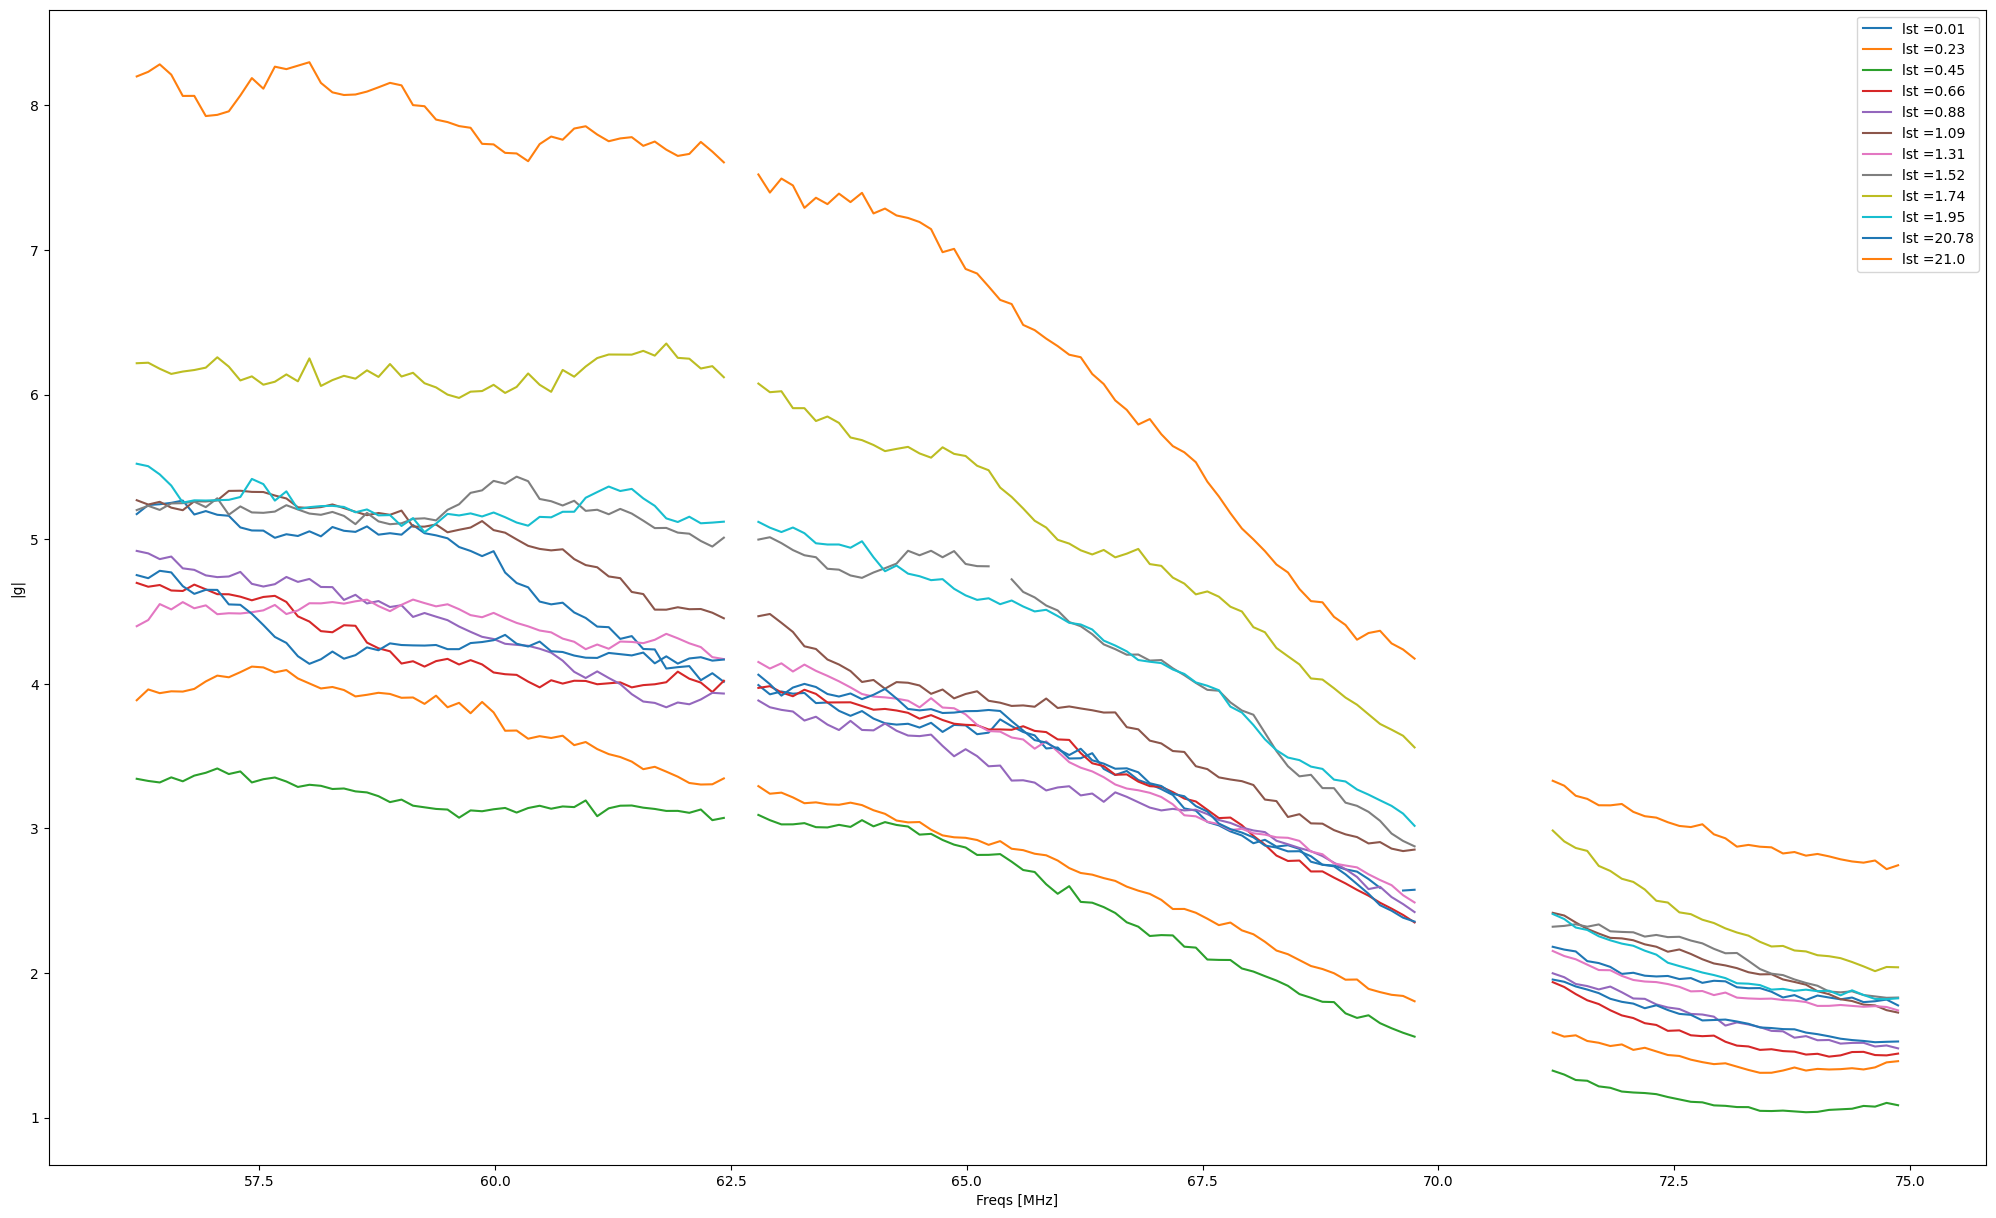

In [24]:
plt.figure(figsize=(25,15))
produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_full, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

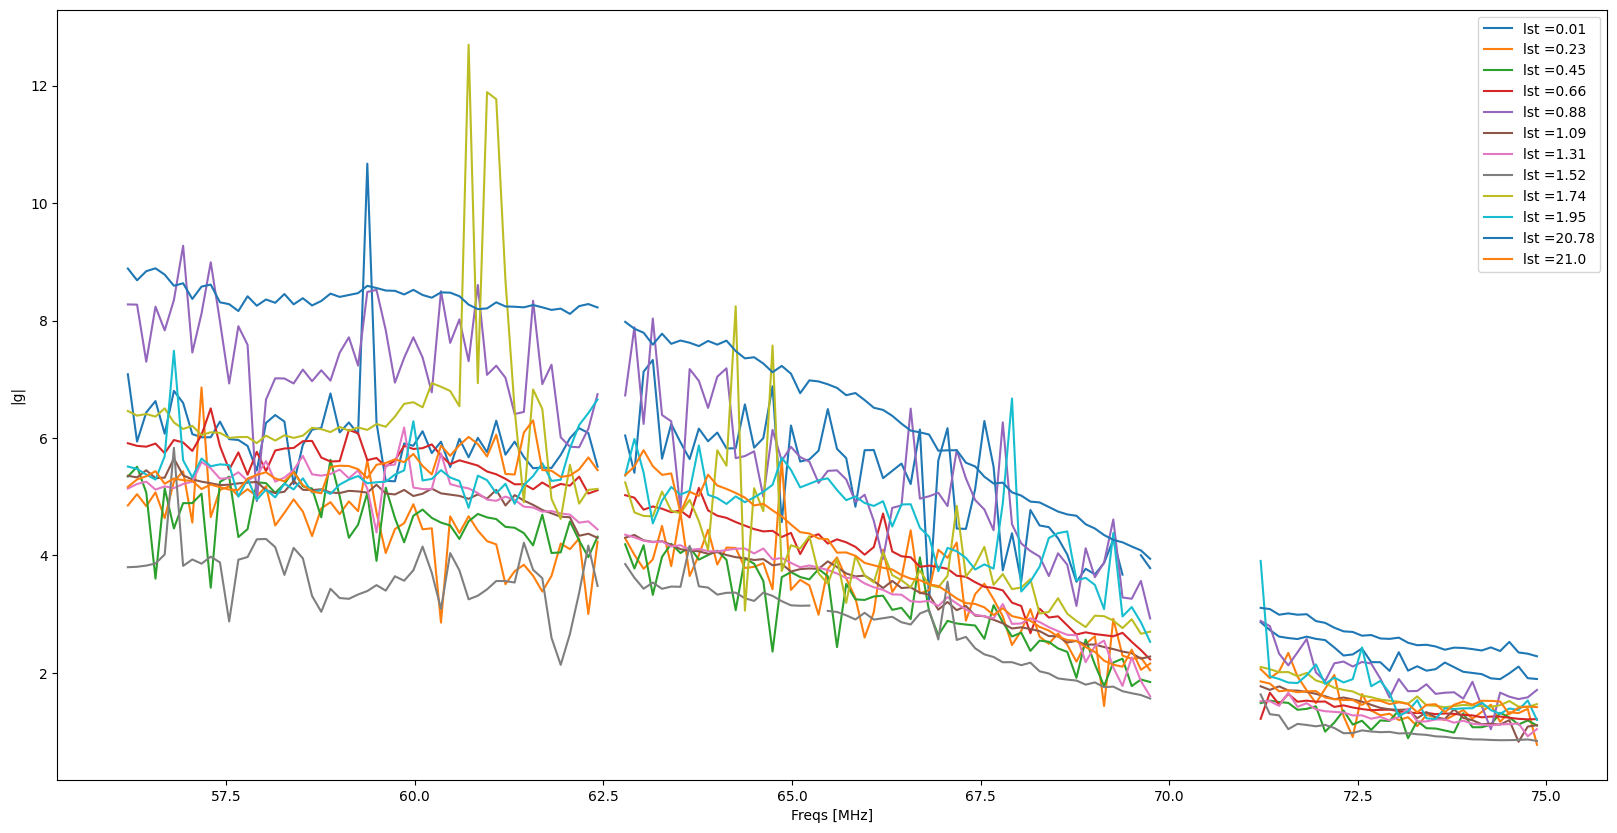

In [25]:

plt.figure(figsize=(20,10))
produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter_notch, lsts=lsts)

# Subset of freqs

Text(0, 0.5, '|g|')

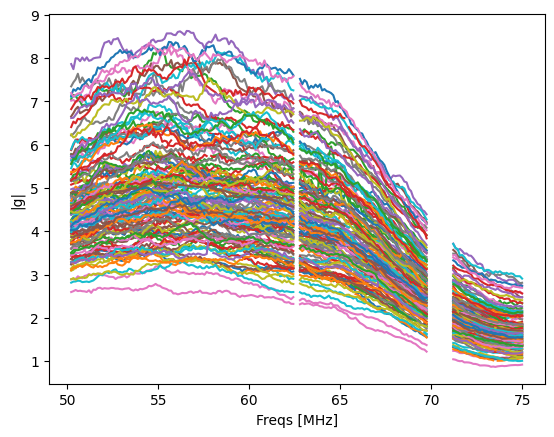

In [26]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [27]:
len(gains_gleam)


125

Text(0, 0.5, '|g|')

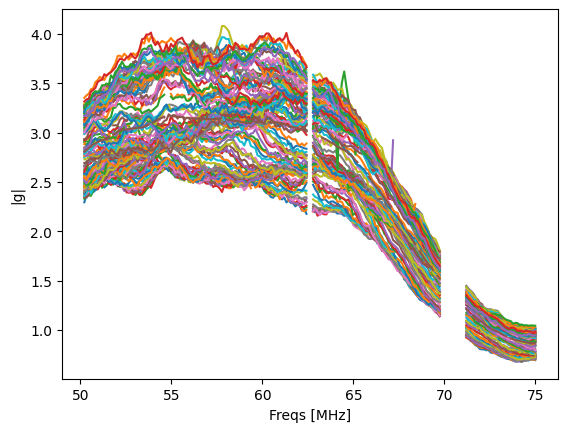

In [28]:

for i in range (gains_full.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

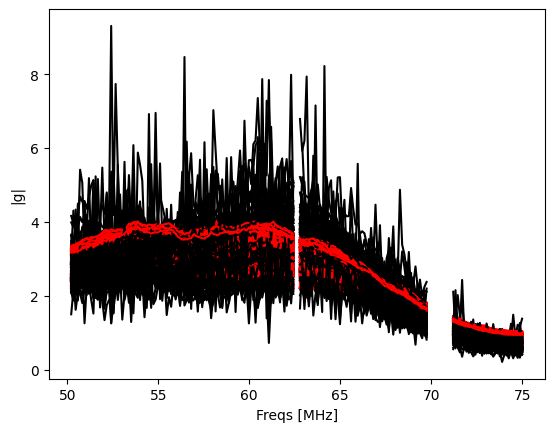

In [29]:

for i in range (gains_full_filter.shape[0]):
    g=np.abs(gains_full_filter_notch[i,x:y])
    g2=np.abs(gains_full[i,x:y])
    g2_av=np.nanmean(g2)
    # print(g.shape, g2.shape, g2_av)
    g3=(g/np.nanmean(g))*g2_av
    plt.plot(freqs[x:y],np.abs(g3),'k')
    plt.plot(freqs[x:y],np.abs(g2),'r')

# plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

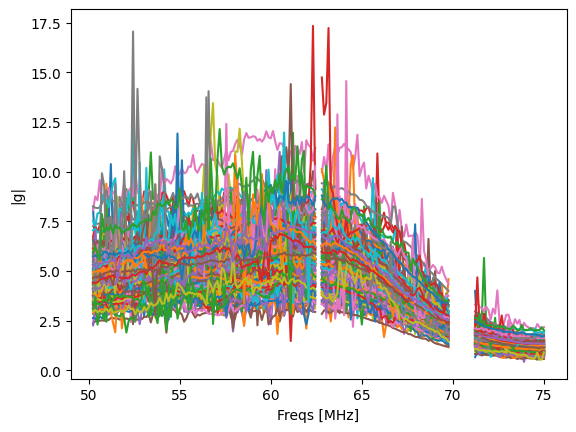

In [30]:

for i in range (gains_full_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

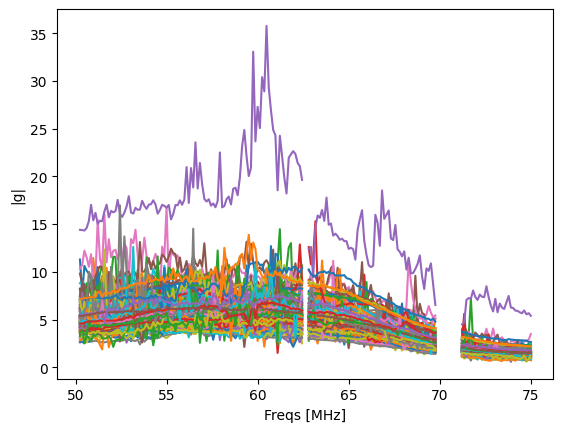

In [31]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

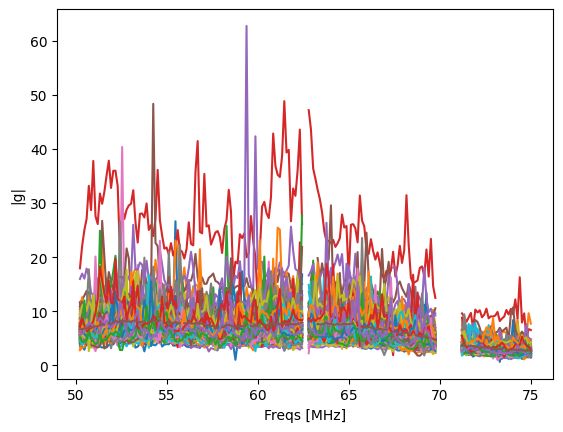

In [32]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

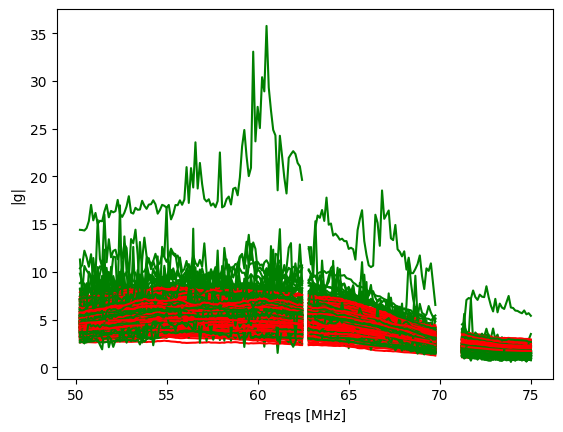

In [33]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]), 'g')
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]), 'r')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'g')  
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r')  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

## Avarage gain amplitude

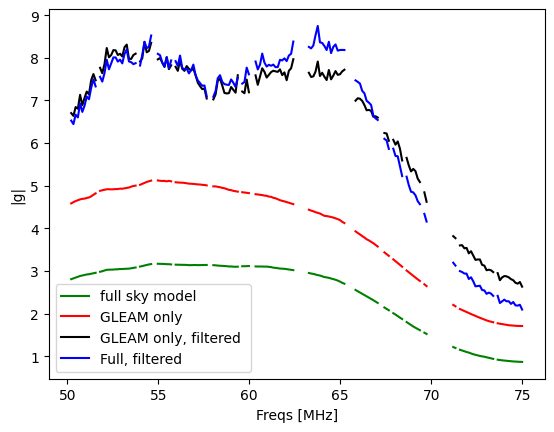

In [34]:
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'g', label="full sky model") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter[:,x:y]), axis=0)),'k', label="GLEAM only, filtered ") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter[:,x:y]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

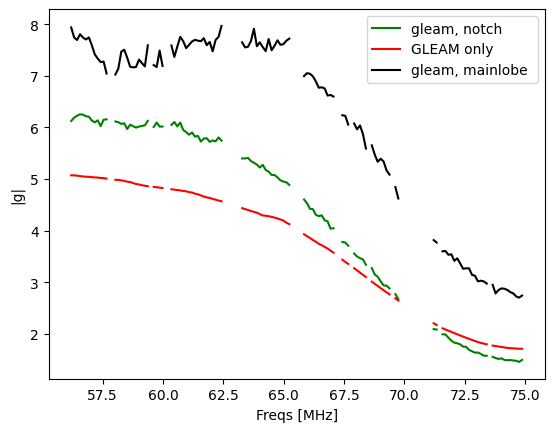

In [35]:
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,50:-1]), axis=0)),'g', label="gleam, notch") 
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam[:,50:-1]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam_filter[:,50:-1]), axis=0)),'k', label="gleam, mainlobe ") 
# plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full_filter_notch[:,50:-1]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

## Delay Transform average gain

In [36]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=""):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    g0_delay=np.mean(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted))),axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted, g0_delay, tau_pos





In [37]:
def produce_plots_delay(n,N):
    
    x,y=0,205
    gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full[n:N,x:y])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam[n:N,x:y])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter[n:N,x:y])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter[n:N,x:y])
    gains_full_filter_ave_notch, g4, full_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter_notch[n:N,x:y])
    gains_gleam_filter_ave_notch, g5, gleam_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter_notch[n:N,x:y])
    
    
    
    plt.plot(freqs[x:y], gains_full_ave,'k', label="full")
    plt.plot(freqs[x:y], gains_gleam_ave, 'r', label="gleam")
    plt.plot(freqs[x:y], gains_gleam_filter_ave, 'g', label="gleam filter")
    plt.plot(freqs[x:y], gains_full_filter_ave, 'm', label="full filter")
    plt.plot(freqs[x:y], gains_gleam_filter_ave_notch, 'c', label="notch gleam filter")
    plt.plot(freqs[x:y], gains_full_filter_ave_notch, 'b', label="notch full filter")
    
    plt.xlabel("Freq[MHz]")
    plt.ylabel("$|g(\\nu)|$")
    plt.legend()
    plt.figure()
    # print(tau_pos, gleam_delay)
    plt.semilogy(tau_pos, full_delay,'k')
    plt.semilogy(tau_pos, gleam_delay,'r')
    plt.semilogy(tau_pos, gleam_filter_delay,'g')
    plt.semilogy(tau_pos, full_filter_delay,'m')
    plt.semilogy(tau_pos, full_filter_notch_delay,'b')
    plt.semilogy(tau_pos, gleam_filter_notch_delay,'m')

    # plt.semilogy(tau_pos, full_delay/np.max(full_delay),'k')
    # plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'r')
    # plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    # plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    # plt.semilogy(tau_pos, full_filter_notch_delay/np.max(full_filter_notch_delay),'b')
    # plt.semilogy(tau_pos, gleam_filter_notch_delay/np.max(gleam_filter_notch_delay),'m')
    # plt.xlabel("Delay $\\tau$ [ns]")
    # plt.ylabel("$|g(\\tau)|$")
    
    plt.xlim([0,4500])

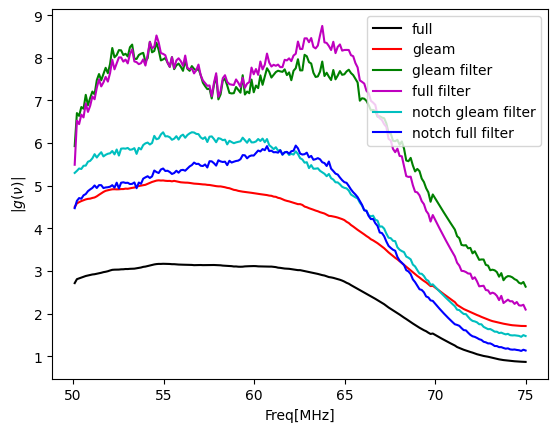

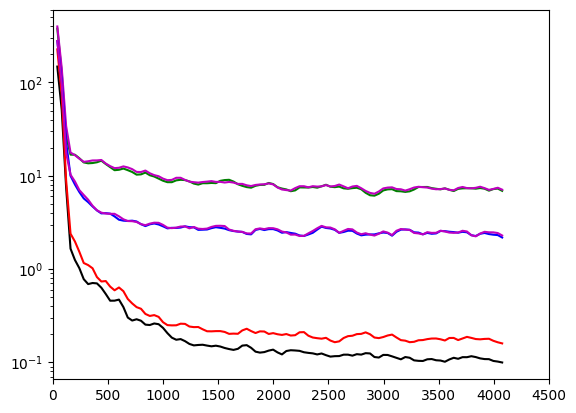

In [39]:
produce_plots_delay(n=0,N=len(gains_full))

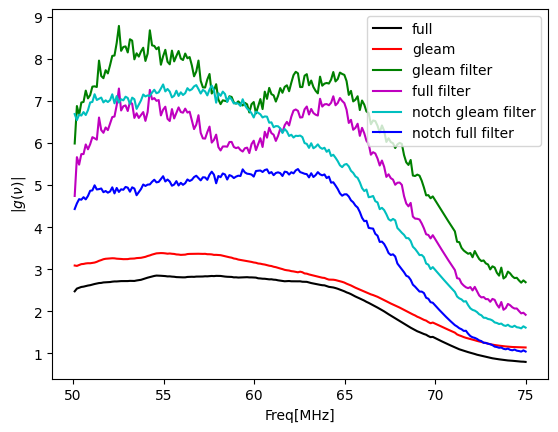

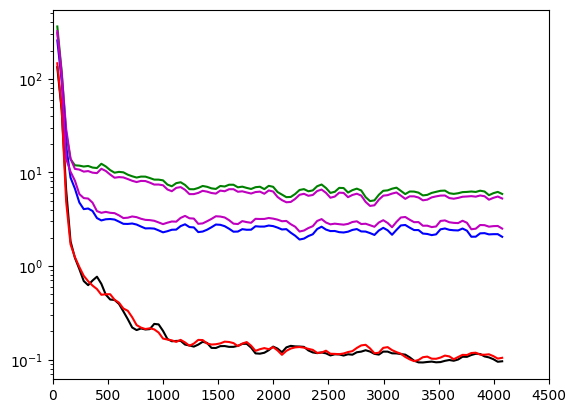

In [76]:
produce_plots_delay(n=0,N=70)

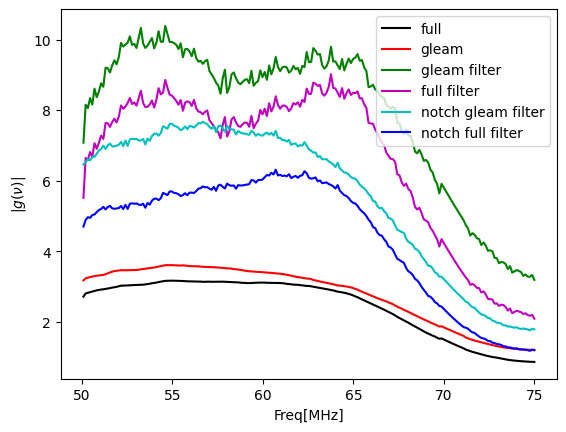

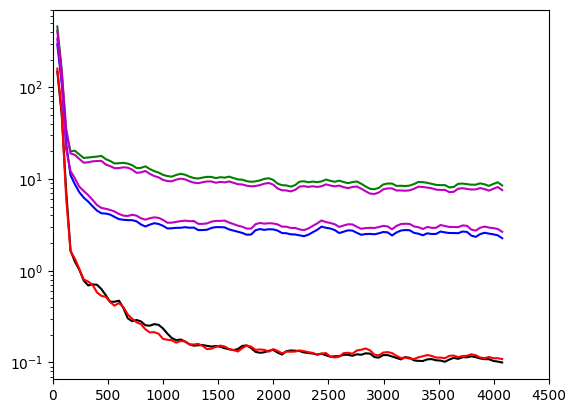

In [77]:
produce_plots_delay(n=0,N=len(gains_full))

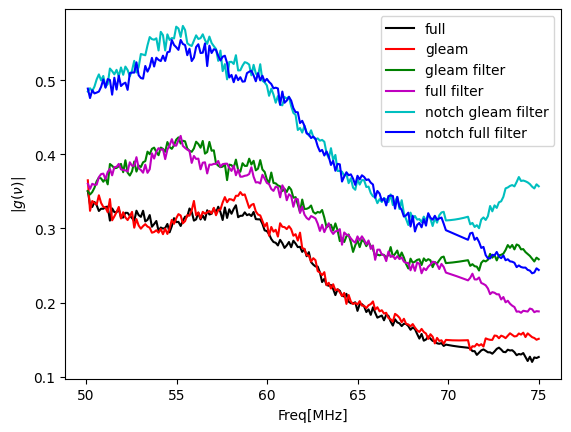

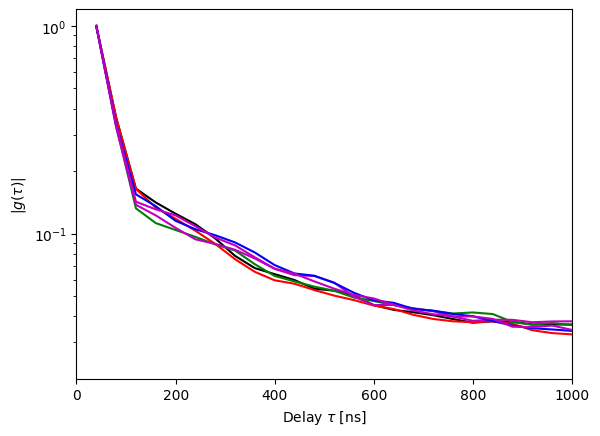

In [169]:
produce_plots_delay(n=3,N=250)

In [40]:
lsts[0]

np.float64(0.014352717191858355)

In [41]:
lsts[100]

np.float64(2.1677157438136474)

In [60]:
40*60*100.0

240000.0

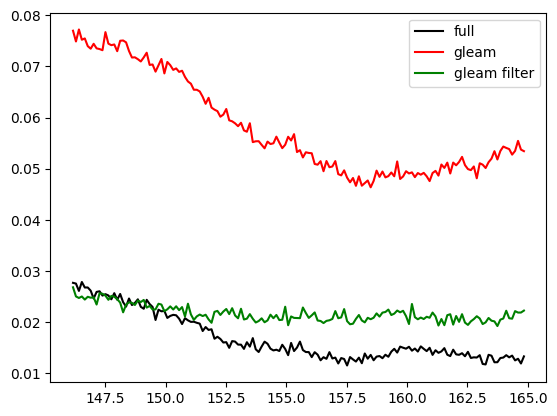

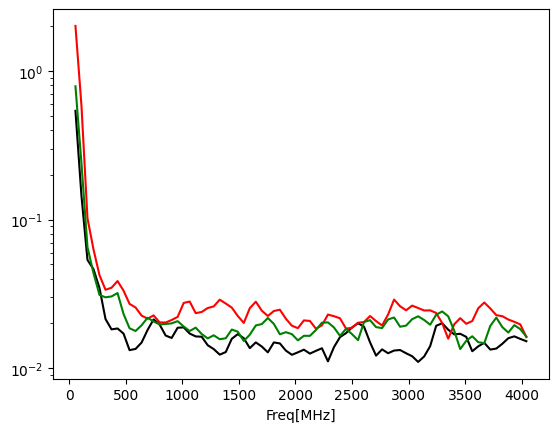

In [59]:
produce_plots_delay(n=50,N=70)

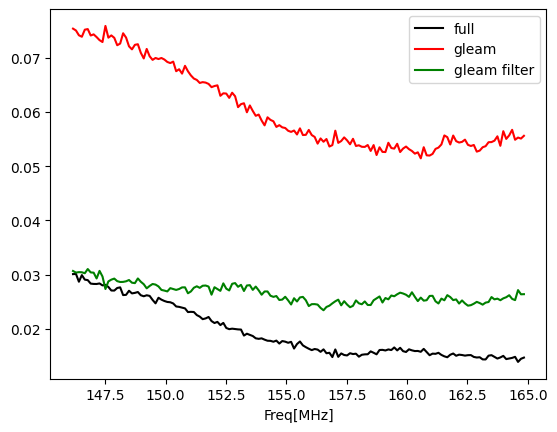

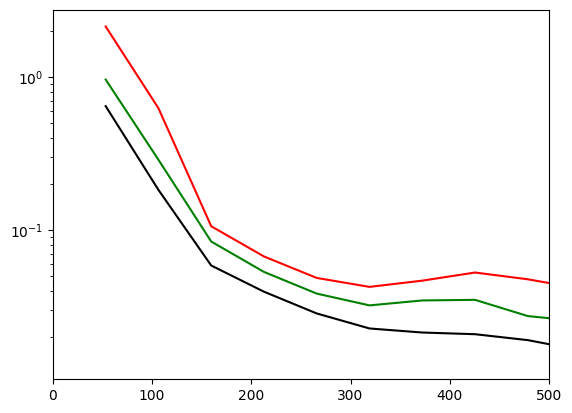

In [63]:
produce_plots_delay(n=0,N=100)

In [77]:
gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[90:100,50:-1])
gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[90:100,50:-1])
gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam_filter[90:100,50:-1])
gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full_filter[90:100,50:-1])


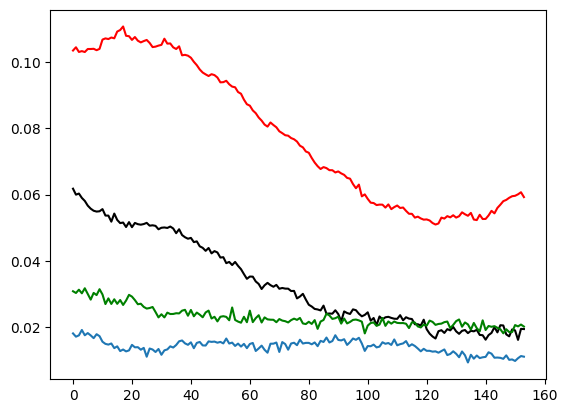

In [78]:
plt.plot(gains_full_ave,'k')
plt.plot(gains_gleam_ave, 'r')
plt.plot(gains_gleam_filter_ave, 'g')
plt.plot(gains_full_filter_ave)

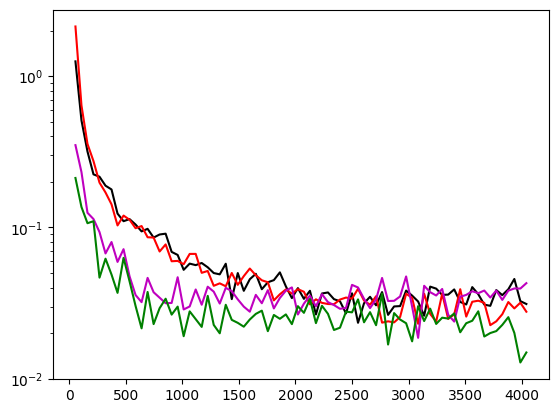

In [79]:
plt.semilogy(tau_pos, full_delay,'k')
plt.semilogy(tau_pos, gleam_delay,'r')
plt.semilogy(tau_pos, gleam_filter_delay,'m')
plt.semilogy(tau_pos, full_filter_delay,'g')
# plt.xlim([0,5000])

## Chis-sqaure

In [61]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [62]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_Notch_filter_40_mHz_redcal_"+uvh5name[i]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

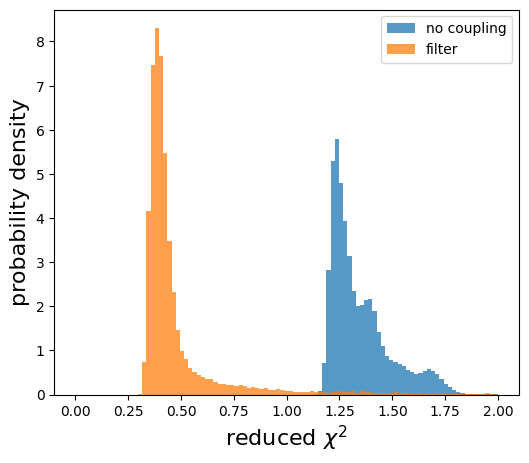

In [63]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="no coupling")
plt.hist(np.abs(chis_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [9]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [12]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [13]:
pol=hd.polarization_array

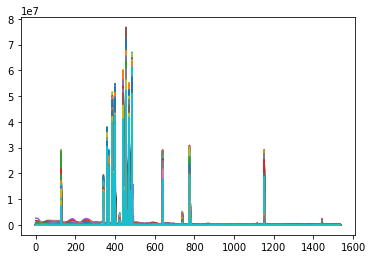

In [14]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [21]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [22]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



divide by zero encountered in log
divide by zero encountered in log
invalid value encountered in exp


In [23]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




invalid value encountered in true_divide
invalid value encountered in greater
invalid value encountered in greater


In [24]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

AttributeError: 'dict' object has no attribute 'gains'

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [27]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


KeyError: "Unable to open object (object 'phase_type' doesn't exist)"

In [69]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

Selected 134 data baselines and 134 model baselines to load.


In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [28]:
hc.abscal.post_redcal_abscal??

Signature:
hc.abscal.post_redcal_abscal(
    model,
    data,
    data_wgts,
    rc_flags,
    edge_cut=0,
    tol=1.0,
    kernel=(1, 15),
    phs_max_iter=100,
    phs_conv_crit=1e-06,
    verbose=True,
)
Source:   
def post_redcal_abscal(model, data, data_wgts, rc_flags, edge_cut=0, tol=1.0, kernel=(1, 15),
                       phs_max_iter=100, phs_conv_crit=1e-6, verbose=True):
    '''Performs Abscal for data that has already been redundantly calibrated.

    Arguments:
        model: DataContainer containing externally calibrated visibilities, LST-matched to the data.
            The model keys must match the data keys.
        data: DataContainer containing redundantly but not absolutely calibrated visibilities. This gets modified.
        data_wgts: DataContainer containing same keys as data, determines their relative weight in the abscal
            linear equation solvers.
        rc_flags: dictionary mapping keys like (1, 'Jnn') to flag waterfalls from redundant calibratio